In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
import warnings 
warnings.filterwarnings("ignore")

In [3]:
tracks = pd.read_csv("tracks.csv", header=[0,1], index_col=0)
tracks.head()

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [4]:
features = pd.read_csv("features.csv", header=[0,1,2], index_col=0)
features.head()

feature    chroma_cens                                                    \
statistics    kurtosis                                                     
number              01        02        03        04        05        06   
track_id                                                                   
2             7.180653  5.230309  0.249321  1.347620  1.482478  0.531371   
3             1.888963  0.760539  0.345297  2.295201  1.654031  0.067592   
5             0.527563 -0.077654 -0.279610  0.685883  1.937570  0.880839   
10            3.702245 -0.291193  2.196742 -0.234449  1.367364  0.998411   
20           -0.193837 -0.198527  0.201546  0.258556  0.775204  0.084794   

feature                                             ...   tonnetz            \
statistics                                          ...       std             
number            07        08        09        10  ...        04        05   
track_id                                            ...                       
2           1.481593  2.691455  0.866868  1.341231  ...  0.054125  0.012226   
3           1.366848  1.054094  0.108103  0.619185  ...  0.063831  0.014212   
5          -0.923192 -0.927232  0.666617  1.038546  ...  0.040730  0.012691   
10          1.770694  1.604566  0.521217  1.982386  ...  0.074358  0.017952   
20         -0.289294 -0.816410  0.043851 -0.804761  ...  0.095003  0.022492   

feature                     zcr                                          \
statistics             kurtosis       max      mean    median       min   
number            06         01        01        01        01        01   
track_id                                                                  
2           0.012111   5.758890  0.459473  0.085629  0.071289  0.000000   
3           0.017740   2.824694  0.466309  0.084578  0.063965  0.000000   
5           0.014759   6.808415  0.375000  0.053114  0.041504  0.000000   
10          0.013921  21.434212  0.452148  0.077515  0.071777  0.000000   
20          0.021355  16.669037  0.469727  0.047225  0.040039  0.000977   

feature                         
statistics      skew       std  
number            01        01  
track_id                        
2           2.089872  0.061448  
3           1.716724  0.069330  
5           2.193303  0.044861  
10          3.542325  0.040800  
20          3.189831  0.030993  

[5 rows x 518 columns]

In [5]:
tracks.columns = ["__".join(map(str, col)) for col in tracks.columns]
features.columns = ["__".join(map(str, col)) for col in features.columns]

In [6]:
tracks.shape

(106574, 52)

In [7]:
features.shape

(106574, 518)

In [8]:
df = features.join(
    tracks["track__genre_top"].rename("target"),
    how="inner"
)

df = df.join(
    tracks["track__tags"].rename("tags")
)

df = df.dropna(subset=["target"])
df.head()

,chroma_cens__kurtosis__01,chroma_cens__kurtosis__02,chroma_cens__kurtosis__03,chroma_cens__kurtosis__04,chroma_cens__kurtosis__05,chroma_cens__kurtosis__06,chroma_cens__kurtosis__07,chroma_cens__kurtosis__08,chroma_cens__kurtosis__09,chroma_cens__kurtosis__10,...,tonnetz__std__06,zcr__kurtosis__01,zcr__max__01,zcr__mean__01,zcr__median__01,zcr__min__01,zcr__skew__01,zcr__std__01,target,tags
track_id,,,,,,,,,,,,,,,,,,,,,
2,7.180653,5.230309,0.249321,1.347620,1.482478,0.531371,1.481593,2.691455,0.866868,1.341231,...,0.012111,5.758890,0.459473,0.085629,0.071289,0.0,2.089872,0.061448,Hip-Hop,[]
3,1.888963,0.760539,0.345297,2.295201,1.654031,0.067592,1.366848,1.054094,0.108103,0.619185,...,0.017740,2.824694,0.466309,0.084578,0.063965,0.0,1.716724,0.069330,Hip-Hop,[]
5,0.527563,-0.077654,-0.279610,0.685883,1.937570,0.880839,-0.923192,-0.927232,0.666617,1.038546,...,0.014759,6.808415,0.375000,0.053114,0.041504,0.0,2.193303,0.044861,Hip-Hop,[]
10,3.702245,-0.291193,2.196742,-0.234449,1.367364,0.998411,1.770694,1.604566,0.521217,1.982386,...,0.013921,21.434212,0.452148,0.077515,0.071777,0.0,3.542325,0.040800,Pop,[]
134,0.918445,0.674147,0.577818,1.281117,0.933746,0.078177,1.199204,-0.175223,0.925482,1.438509,...,0.015819,4.731087,0.419434,0.064370,0.050781,0.0,1.806106,0.054623,Hip-Hop,[]


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49598 entries, 2 to 155319
Columns: 520 entries, chroma_cens__kurtosis__01 to tags
dtypes: float64(518), object(2)
memory usage: 197.1+ MB


In [10]:
df.describe()

,chroma_cens__kurtosis__01,chroma_cens__kurtosis__02,chroma_cens__kurtosis__03,chroma_cens__kurtosis__04,chroma_cens__kurtosis__05,chroma_cens__kurtosis__06,chroma_cens__kurtosis__07,chroma_cens__kurtosis__08,chroma_cens__kurtosis__09,chroma_cens__kurtosis__10,...,tonnetz__std__04,tonnetz__std__05,tonnetz__std__06,zcr__kurtosis__01,zcr__max__01,zcr__mean__01,zcr__median__01,zcr__min__01,zcr__skew__01,zcr__std__01
count,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,...,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000,49598.000000
mean,0.245615,0.170459,0.287549,0.157709,0.174060,0.218822,0.223470,0.264622,0.173848,0.261763,...,0.095044,0.020807,0.021161,27.049015,0.378727,0.055122,0.046134,0.002663,3.026455,0.040234
std,6.986728,6.725216,5.481772,2.211588,2.309754,2.383670,9.948680,3.539944,2.325182,8.855109,...,0.035279,0.005926,0.005958,86.646205,0.181512,0.033143,0.032640,0.005508,2.914268,0.027163
min,-1.955806,-1.936607,-1.967450,-1.939882,-1.921206,-1.914996,-1.907819,-3.000000,-3.000000,-1.873126,...,0.010322,0.004619,0.003994,-1.967539,0.017578,0.000112,0.000000,0.000000,-15.727972,0.001356
25%,-0.600678,-0.622513,-0.589285,-0.605398,-0.628423,-0.582207,-0.606991,-0.594360,-0.632567,-0.632890,...,0.069212,0.016576,0.016954,2.983900,0.243652,0.035247,0.026855,0.000000,1.295365,0.022100
50%,-0.132662,-0.170565,-0.110621,-0.144119,-0.163440,-0.106924,-0.145082,-0.111697,-0.171527,-0.146576,...,0.089617,0.019746,0.020156,8.894965,0.355957,0.049836,0.040527,0.000488,2.280386,0.033110
75%,0.542525,0.472097,0.573309,0.500378,0.492136,0.559864,0.523409,0.584807,0.499129,0.534670,...,0.115914,0.024014,0.024322,24.676008,0.467285,0.067009,0.057617,0.003418,3.848473,0.050961
max,1466.929565,1440.969116,734.007202,311.448517,193.075623,211.774948,2174.952637,439.131195,188.034485,1772.918213,...,0.316604,0.092869,0.101122,8438.014648,0.999512,0.878024,0.895996,0.262207,75.709999,0.424317


In [11]:
df["target"]

track_id
2         Hip-Hop
3         Hip-Hop
5         Hip-Hop
10            Pop
134       Hip-Hop
           ...   
155315       Rock
155316       Rock
155317       Rock
155318       Rock
155319       Rock
Name: target, Length: 49598, dtype: object

In [12]:
genre_counts = df["target"].value_counts()
valid_genres = genre_counts[genre_counts > 300].index
df = df[df["target"].isin(valid_genres)]

Distribucija žanrova
target
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Name: count, dtype: int64


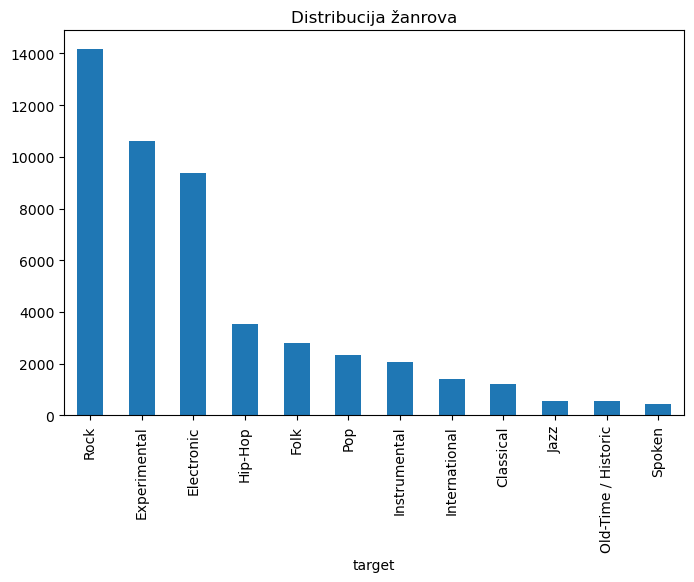

In [13]:
import matplotlib.pyplot as plt

print("Distribucija žanrova")
print(df["target"].value_counts())

plt.figure(figsize=(8,5))
df["target"].value_counts().plot(kind="bar")
plt.title("Distribucija žanrova")
plt.show()

In [14]:
X = df.drop(columns=["target"])
y = df["target"]

X_num = X.drop(columns=["tags"])
tags = X["tags"].fillna("")

In [15]:
import ast

def clean_tags(x):
    if pd.isna(x):
        return ""
    try:
        t = ast.literal_eval(x)

        if isinstance(t, list):
            return " ".join(tag.lower() for tag in t)
    except:
        pass
    return ""

tags = tags.apply(clean_tags)

print("Primer tagova:")
print(tags[tags != ""].head(20))

print("\nBroj pesama sa tagovima:", (tags != "").sum())

Primer tagova:
track_id
137             lafms
138             lafms
850         baltimore
851         baltimore
852         baltimore
870      portland pdx
991         baltimore
992         baltimore
993         baltimore
1038        baltimore
1049        baltimore
1050        baltimore
1243        baltimore
1245        baltimore
1249        baltimore
1253        baltimore
1258        baltimore
1261        baltimore
1264        baltimore
1476    sound collage
Name: tags, dtype: object

Broj pesama sa tagovima: 8672


In [16]:
unique_tags = set()

for t in tags:
    if t != "":
        unique_tags.update(t.split())

print("Ukupan broj različitih tagova:", len(unique_tags))

print("\nPrimer različitih tagova:")
print(sorted(list(unique_tags))[:50])

Ukupan broj različitih tagova: 2850

Primer različitih tagova:
['-', '0030', '00s', '1', '16-paral-lel', '1920-antique', '1950s', '1980s', '1984', '1994', '1995', '1996-1998', '1dance', '1intro', '2', '20', '2011', '2013', '2016', '2017', '20th', '24-bit', '27', '2nd', '2ndmouse', '2step', '3a', '3b', '500', '5000', '50th', '5am', '70s', '8', '80s', '8bit', '8bitpeoples', '8m2stereo', '90s', 'a', 'aap', 'abc100', 'abe', 'abq', 'abraka', 'abstract', 'abstraction', 'abstruct', 'absurdities', 'acapella']


In [17]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

X_all = X_num.astype(np.float32).values

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_all)

print("All:", X_all.shape)
print("PCA:", X_pca.shape)

All: (49095, 518)
PCA: (49095, 30)


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train_all, X_test_all, tags_train, tags_test, y_train, y_test = train_test_split(
    X_all,
    tags,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_text_train = tfidf.fit_transform(tags_train)
X_text_test = tfidf.transform(tags_test)

In [22]:
from scipy.sparse import csr_matrix
from scipy.sparse import hstack

X_train_all = csr_matrix(X_train_all)
X_test_all = csr_matrix(X_test_all)

X_train_all = hstack([X_train_all, X_text_train])
X_test_all = hstack([X_test_all, X_text_test])

print("ALL shape:", X_train_all.shape)

ALL shape: (39276, 2518)


In [23]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector_red = SelectKBest(mutual_info_classif, k=1200)

X_train_red = selector_red.fit_transform(X_train_all, y_train)
X_test_red = selector_red.transform(X_test_all)

print("ALL shape:", X_train_all.shape)
print("RED shape:", X_train_red.shape)

ALL shape: (39276, 2518)
RED shape: (39276, 1200)


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, normalize="true")

    fig, ax = plt.subplots(figsize=(10,8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )
    disp.plot(
        cmap="Blues",
        xticks_rotation=45,
        ax=ax,
        values_format=".2f"
    )

    plt.title(f"Normalized Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

In [26]:
#!pip install lightgbm

In [27]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

lgbm_red = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.848020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 135260
[LightGBM] [Info] Number of data points in the train set: 39276, number of used features: 2355
[LightGBM] [Info] Start training from score -3.686743
[LightGBM] [Info] Start training from score -1.655977
[LightGBM] [Info] Start training from score -1.532196
[LightGBM] [Info] Start training from score -2.863245
[LightGBM] [Info] Start training from score -2.626106
[LightGBM] [Info] Start training from score -3.161990
[LightGBM] [Info] Start training from score -3.565353
[LightGBM] [Info] Start training from score -4.453686
[LightGBM] [Info] Start training from score -4.484799
[LightGBM] [Info] Start training from score -3.046817
[LightGBM] [Info] Start training from score -1.241748
[LightGBM] [Info] Start training from score -4.755323
[LightGBM] [Warning] No further splits with positive gain, 

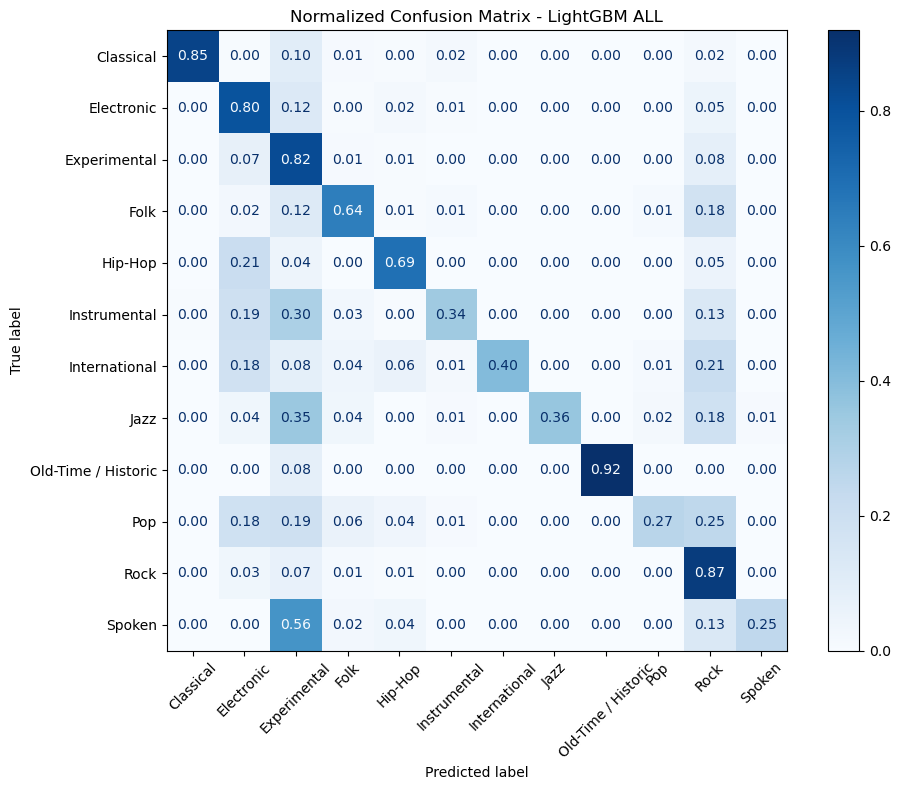

In [28]:
evaluate_model(lgbm, X_train_all, X_test_all, y_train, y_test, "LightGBM ALL")

In [29]:
model_name = "LightGBM_ALL.joblib"
joblib.dump(lgbm, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: LightGBM_ALL.joblib


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.621769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 131460
[LightGBM] [Info] Number of data points in the train set: 39276, number of used features: 1200
[LightGBM] [Info] Start training from score -3.686743
[LightGBM] [Info] Start training from score -1.655977
[LightGBM] [Info] Start training from score -1.532196
[LightGBM] [Info] Start training from score -2.863245
[LightGBM] [Info] Start training from score -2.626106
[LightGBM] [Info] Start training from score -3.161990
[LightGBM] [Info] Start training from score -3.565353
[LightGBM] [Info] Start training from score -4.453686
[LightGBM] [Info] Start training from score -4.484799
[LightGBM] [Info] Start training from score -3.046817
[LightGBM] [Info] Start training from score -1.241748
[LightGBM] [Info] Start training from score -4.755323
[LightGBM] [Warning] No further splits with positive gain, 

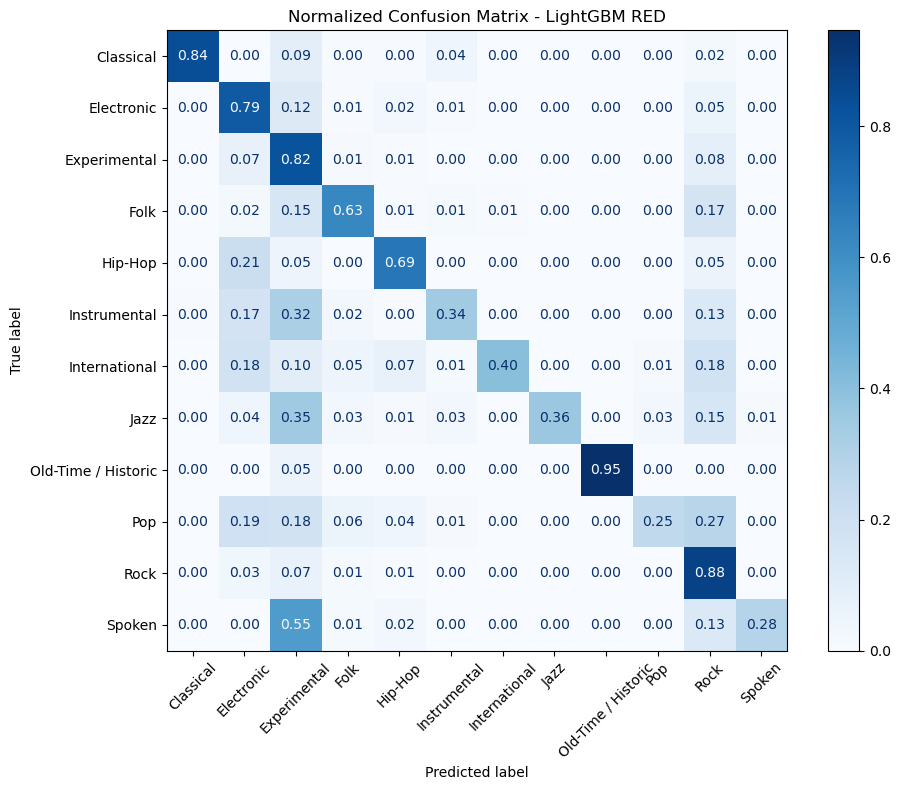

In [30]:
evaluate_model(lgbm_red, X_train_red, X_test_red, y_train, y_test,"LightGBM RED")

In [31]:
model_name = "LightGBM_RED.joblib"
joblib.dump(lgbm_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: LightGBM_RED.joblib


In [27]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

In [33]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=4,
    class_weight="balanced",
    n_jobs=-1
)

rf_red = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=4,
    class_weight="balanced",
    n_jobs=-1
)

RandomForest ALL accuracy: 0.6409

Classification report:
                     precision    recall  f1-score   support

          Classical       0.85      0.76      0.80       246
         Electronic       0.61      0.67      0.64      1874
       Experimental       0.54      0.72      0.61      2122
               Folk       0.67      0.51      0.58       561
            Hip-Hop       0.81      0.48      0.60       710
       Instrumental       0.76      0.15      0.26       416
      International       1.00      0.23      0.37       278
               Jazz       0.90      0.08      0.15       114
Old-Time / Historic       0.96      0.93      0.94       111
                Pop       0.91      0.14      0.24       466
               Rock       0.68      0.84      0.75      2836
             Spoken       0.57      0.29      0.39        85

           accuracy                           0.64      9819
          macro avg       0.77      0.48      0.53      9819
       weighted avg      

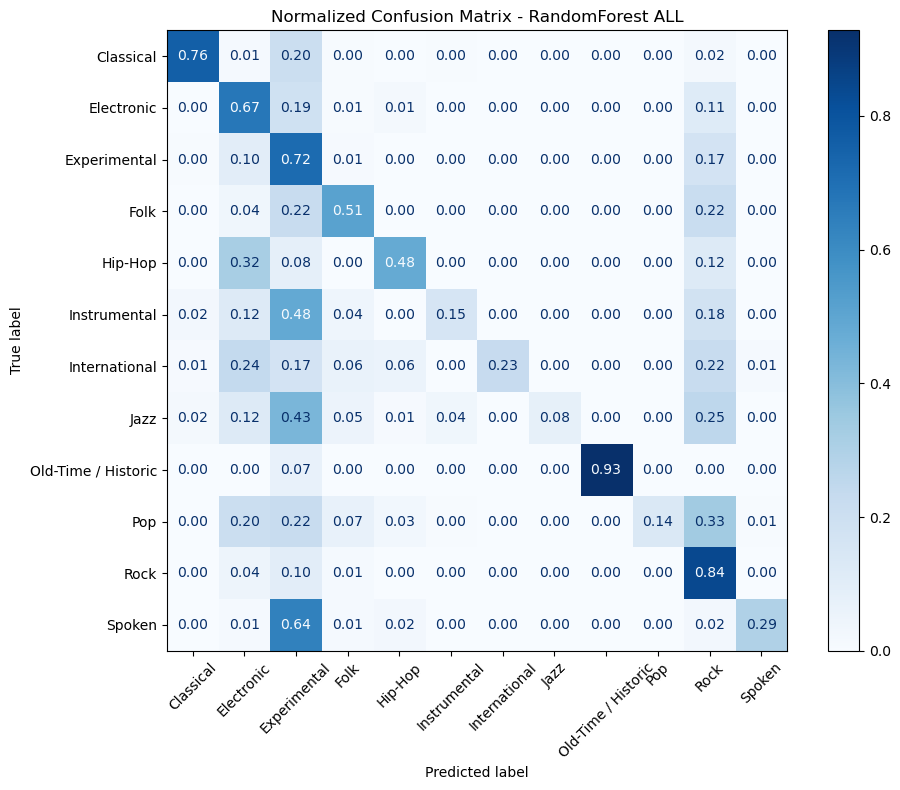

In [34]:
evaluate_model(rf, X_train_all, X_test_all, y_train, y_test, "RandomForest ALL")

In [35]:
model_name = "RandomForest_ALL.joblib"
joblib.dump(rf, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: RandomForest_ALL.joblib


RandomForest RED accuracy: 0.6382

Classification report:
                     precision    recall  f1-score   support

          Classical       0.86      0.75      0.80       246
         Electronic       0.61      0.66      0.63      1874
       Experimental       0.53      0.72      0.61      2122
               Folk       0.65      0.52      0.57       561
            Hip-Hop       0.79      0.49      0.60       710
       Instrumental       0.71      0.14      0.24       416
      International       0.97      0.25      0.40       278
               Jazz       0.90      0.08      0.15       114
Old-Time / Historic       0.96      0.90      0.93       111
                Pop       0.90      0.14      0.24       466
               Rock       0.69      0.83      0.75      2836
             Spoken       0.61      0.32      0.42        85

           accuracy                           0.64      9819
          macro avg       0.77      0.48      0.53      9819
       weighted avg      

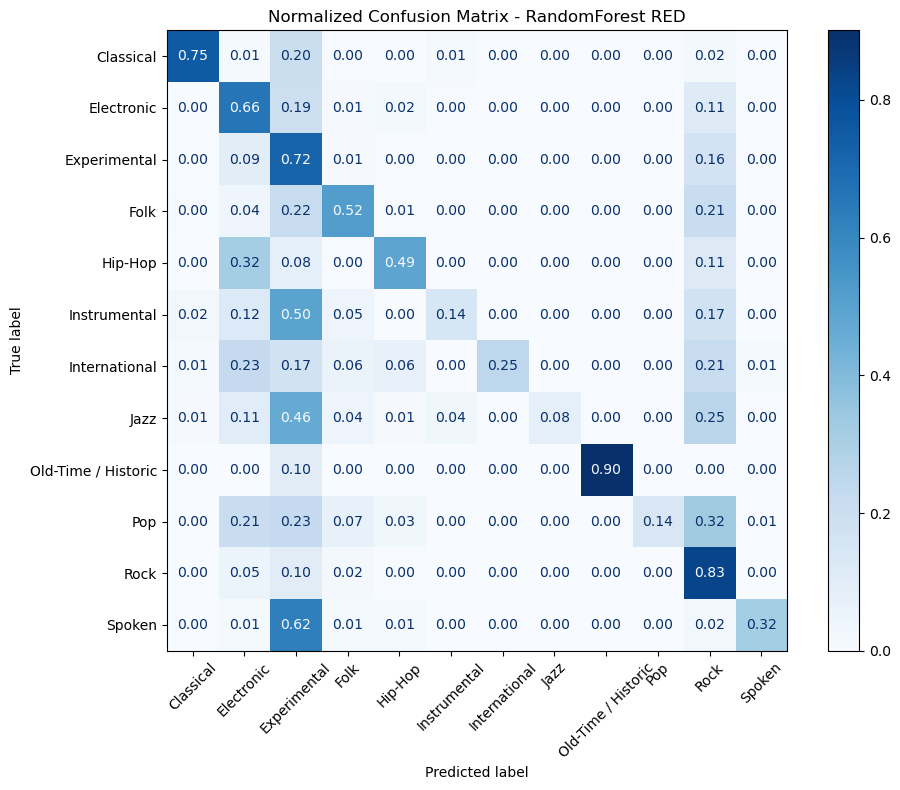

In [36]:
evaluate_model(rf_red, X_train_red, X_test_red, y_train, y_test, "RandomForest RED")

In [37]:
model_name = "RandomForest_RED.joblib"
joblib.dump(rf_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: RandomForest_RED.joblib


Best features shape: (39276, 600)
RandomForest BEST accuracy: 0.6399

Classification report:
                     precision    recall  f1-score   support

          Classical       0.87      0.77      0.82       246
         Electronic       0.61      0.67      0.64      1874
       Experimental       0.53      0.72      0.61      2122
               Folk       0.65      0.52      0.58       561
            Hip-Hop       0.79      0.49      0.61       710
       Instrumental       0.67      0.16      0.25       416
      International       0.93      0.25      0.40       278
               Jazz       0.91      0.09      0.16       114
Old-Time / Historic       0.94      0.93      0.94       111
                Pop       0.90      0.13      0.23       466
               Rock       0.69      0.83      0.75      2836
             Spoken       0.62      0.28      0.39        85

           accuracy                           0.64      9819
          macro avg       0.76      0.49      0.53 

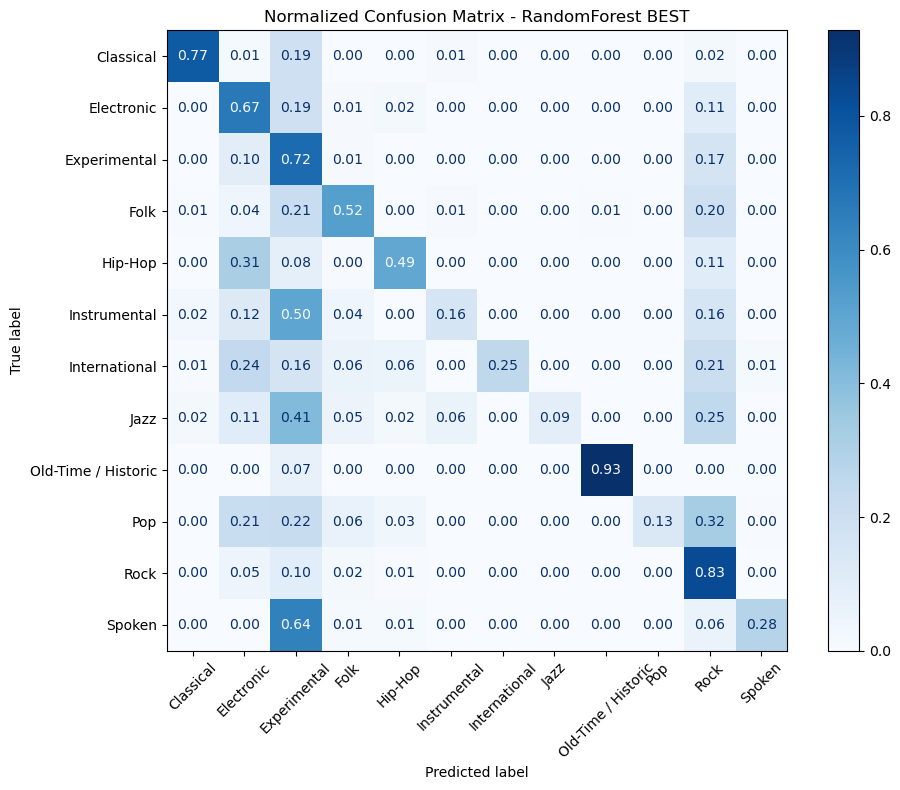

In [38]:
X_train_all = X_train_all.tocsr()
X_test_all = X_test_all.tocsr()

rf.fit(X_train_all, y_train)

importances = rf.feature_importances_

indices = np.argsort(importances)[::-1][:600]

X_train_best = X_train_all[:, indices]
X_test_best = X_test_all[:, indices]

print("Best features shape:", X_train_best.shape)

rf_best = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=4,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

evaluate_model(rf_best, X_train_best, X_test_best, y_train, y_test, "RandomForest BEST")

In [39]:
model_name = "RandomForestClassifier_best"
joblib.dump(rf_best, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: RandomForestClassifier_best


In [40]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

et_red = ExtraTreesClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

ExtraTrees ALL accuracy: 0.6338

Classification report:
                     precision    recall  f1-score   support

          Classical       0.88      0.74      0.80       246
         Electronic       0.62      0.67      0.64      1874
       Experimental       0.54      0.71      0.62      2122
               Folk       0.68      0.44      0.53       561
            Hip-Hop       0.86      0.41      0.55       710
       Instrumental       0.90      0.09      0.16       416
      International       1.00      0.17      0.28       278
               Jazz       1.00      0.01      0.02       114
Old-Time / Historic       0.98      0.86      0.91       111
                Pop       0.91      0.13      0.23       466
               Rock       0.65      0.88      0.74      2836
             Spoken       0.89      0.20      0.33        85

           accuracy                           0.63      9819
          macro avg       0.83      0.44      0.49      9819
       weighted avg       0

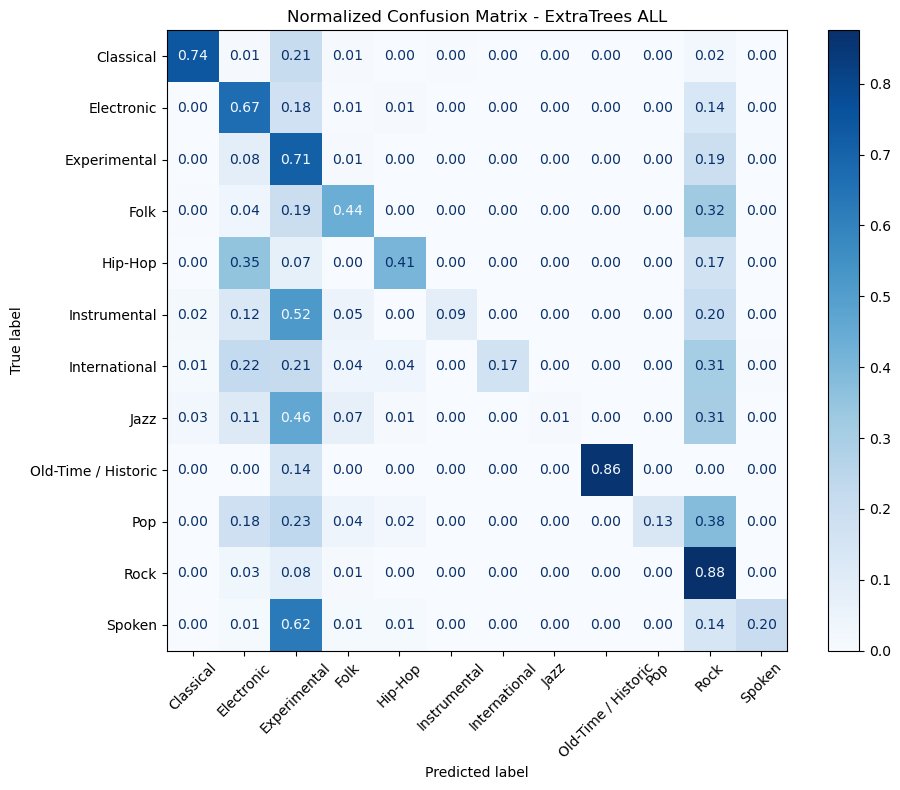

In [41]:
evaluate_model(et, X_train_all, X_test_all, y_train, y_test, "ExtraTrees ALL")

In [42]:
model_name = "ExtraTrees_ALL"
joblib.dump(et, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: ExtraTrees_ALL


ExtraTrees RED accuracy: 0.6370

Classification report:
                     precision    recall  f1-score   support

          Classical       0.88      0.75      0.81       246
         Electronic       0.62      0.67      0.65      1874
       Experimental       0.54      0.71      0.61      2122
               Folk       0.68      0.47      0.55       561
            Hip-Hop       0.86      0.44      0.58       710
       Instrumental       0.79      0.11      0.19       416
      International       1.00      0.18      0.30       278
               Jazz       1.00      0.01      0.02       114
Old-Time / Historic       0.96      0.88      0.92       111
                Pop       0.91      0.13      0.23       466
               Rock       0.66      0.87      0.75      2836
             Spoken       0.95      0.21      0.35        85

           accuracy                           0.64      9819
          macro avg       0.82      0.45      0.50      9819
       weighted avg       0

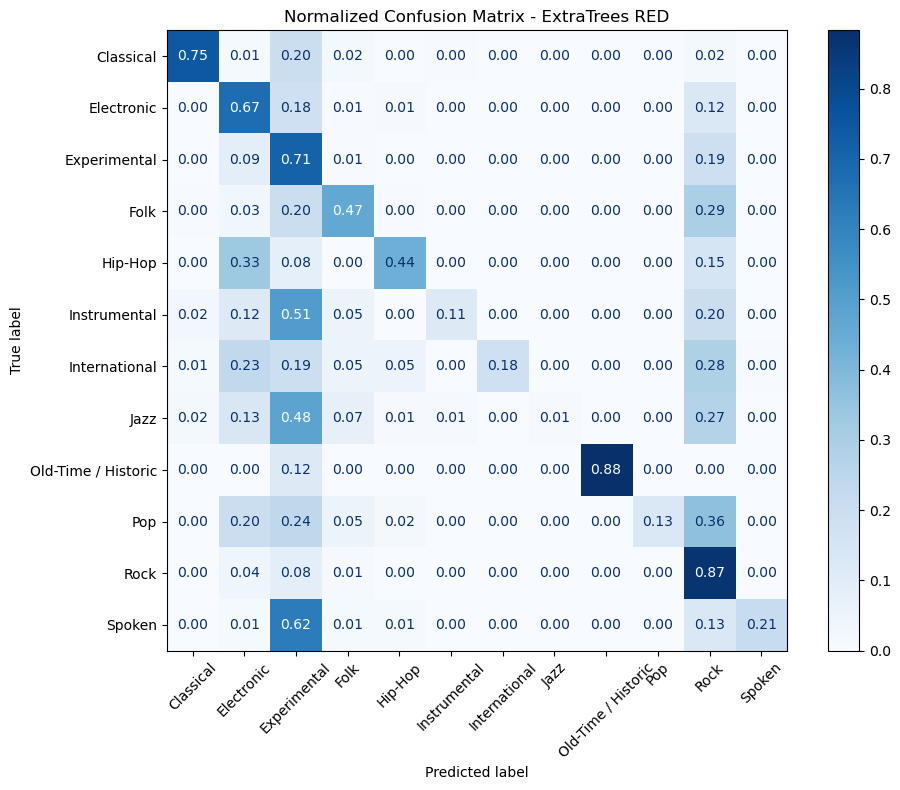

In [43]:
evaluate_model(et_red, X_train_red, X_test_red, y_train, y_test, "ExtraTrees RED")

In [44]:
model_name = "ExtraTreesClassifier_RED"
joblib.dump(et_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: ExtraTreesClassifier_RED


In [28]:
gb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=12
)

gb_red = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=12
)

HistGradientBoosting ALL accuracy: 0.7214

Classification report:
                     precision    recall  f1-score   support

          Classical       0.92      0.83      0.87       246
         Electronic       0.69      0.77      0.72      1874
       Experimental       0.65      0.79      0.71      2122
               Folk       0.68      0.63      0.65       561
            Hip-Hop       0.77      0.68      0.72       710
       Instrumental       0.61      0.31      0.41       416
      International       0.81      0.39      0.52       278
               Jazz       0.70      0.37      0.48       114
Old-Time / Historic       0.97      0.87      0.92       111
                Pop       0.71      0.26      0.38       466
               Rock       0.78      0.86      0.82      2836
             Spoken       0.53      0.19      0.28        85

           accuracy                           0.72      9819
          macro avg       0.74      0.58      0.62      9819
       weighted a

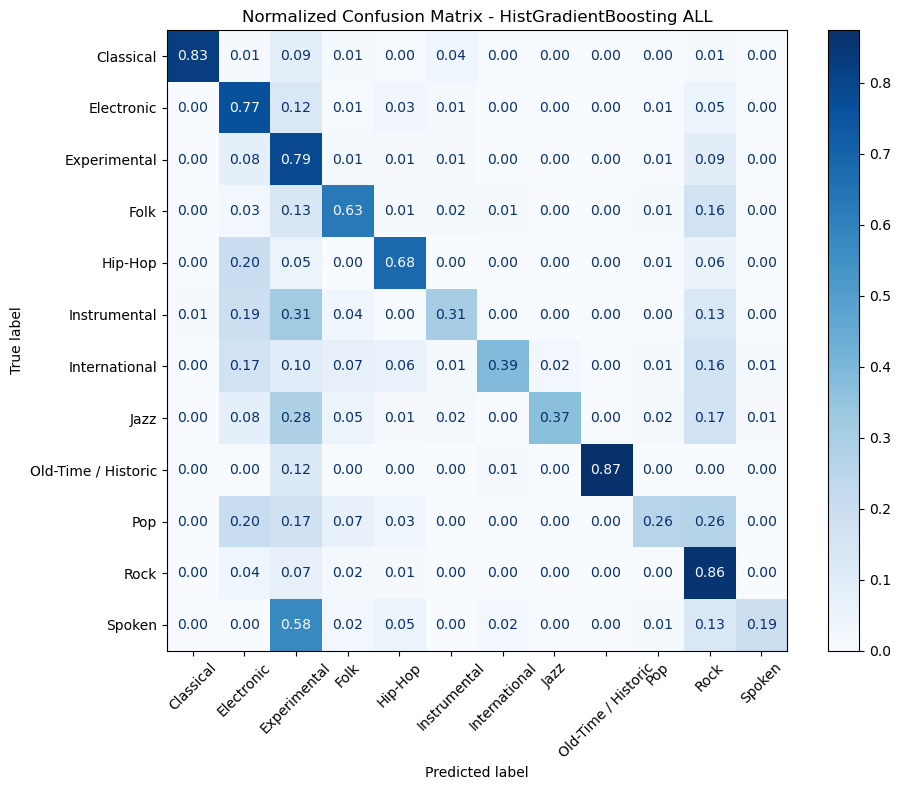

In [29]:
evaluate_model(gb, X_train_all.toarray(), X_test_all.toarray(), y_train, y_test, "HistGradientBoosting ALL")

In [30]:
model_name = "HistGradientBoosting_ALL"
joblib.dump(gb, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: HistGradientBoosting_ALL


HistGradientBoosting RED accuracy: 0.7170

Classification report:
                     precision    recall  f1-score   support

          Classical       0.95      0.84      0.89       246
         Electronic       0.68      0.75      0.71      1874
       Experimental       0.65      0.77      0.70      2122
               Folk       0.66      0.63      0.64       561
            Hip-Hop       0.75      0.68      0.71       710
       Instrumental       0.59      0.34      0.43       416
      International       0.80      0.40      0.53       278
               Jazz       0.76      0.36      0.49       114
Old-Time / Historic       0.97      0.87      0.92       111
                Pop       0.72      0.26      0.39       466
               Rock       0.79      0.86      0.82      2836
             Spoken       0.66      0.27      0.38        85

           accuracy                           0.72      9819
          macro avg       0.75      0.59      0.63      9819
       weighted a

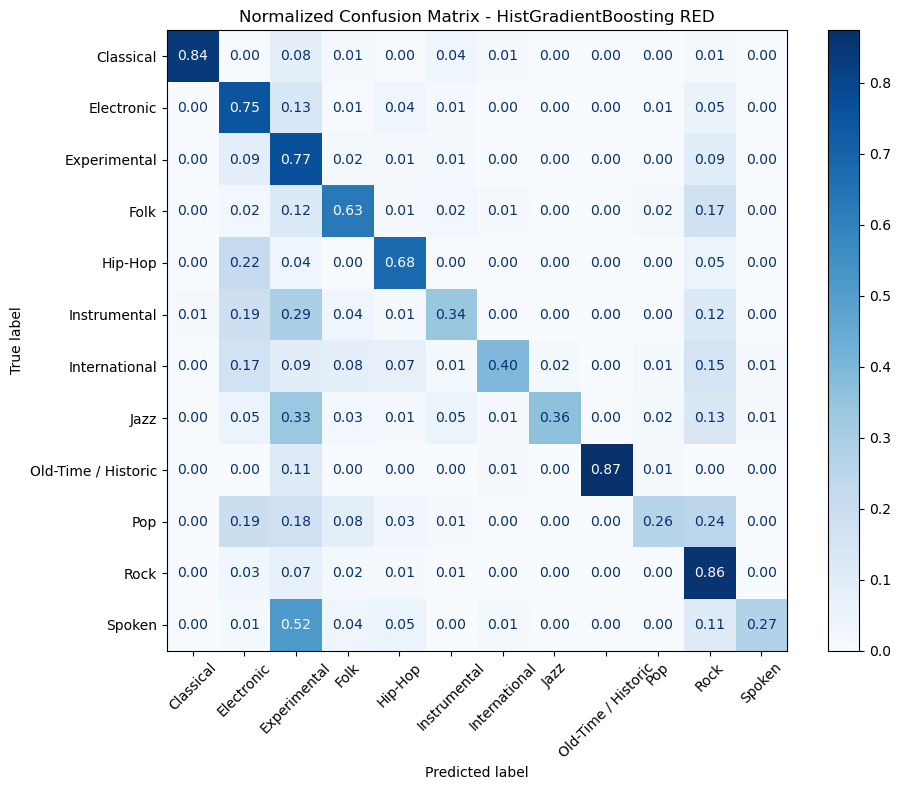

In [31]:
evaluate_model(gb_red, X_train_red.toarray(), X_test_red.toarray(), y_train, y_test, "HistGradientBoosting RED")

In [32]:
model_name = "HistGradientBoostingClassifier_RED"
joblib.dump(gb_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: HistGradientBoostingClassifier_RED


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled = scaler.transform(X_test_all)

scaler_red = StandardScaler(with_mean=False)

X_train_red_scaled = scaler_red.fit_transform(X_train_red)
X_test_red_scaled = scaler_red.transform(X_test_red)

In [34]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    C=2,
    class_weight="balanced",
    max_iter=5000
)

svm_red = LinearSVC(
    C=2,
    class_weight="balanced",
    max_iter=5000
)

SVM ALL accuracy: 0.6778

Classification report:
                     precision    recall  f1-score   support

          Classical       0.80      0.89      0.84       246
         Electronic       0.74      0.65      0.69      1874
       Experimental       0.74      0.59      0.66      2122
               Folk       0.52      0.70      0.60       561
            Hip-Hop       0.60      0.78      0.68       710
       Instrumental       0.41      0.50      0.45       416
      International       0.43      0.64      0.52       278
               Jazz       0.22      0.66      0.33       114
Old-Time / Historic       0.87      0.96      0.91       111
                Pop       0.56      0.27      0.36       466
               Rock       0.83      0.80      0.81      2836
             Spoken       0.30      0.64      0.41        85

           accuracy                           0.68      9819
          macro avg       0.59      0.67      0.61      9819
       weighted avg       0.71    

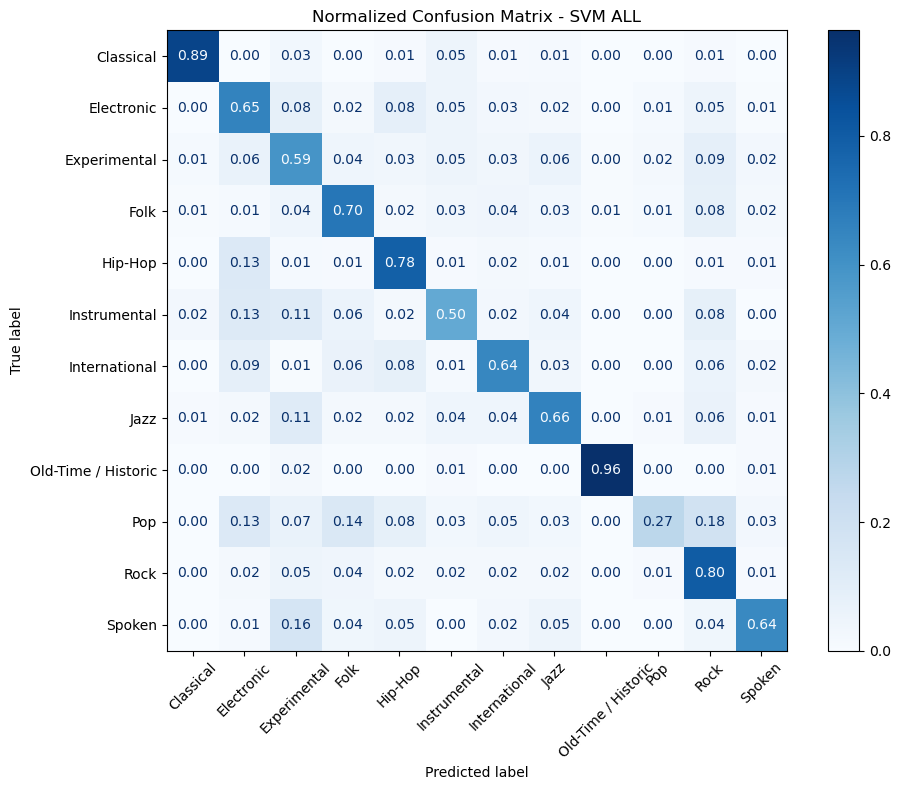

In [35]:
evaluate_model(svm, X_train_scaled, X_test_scaled, y_train, y_test, "SVM ALL")

In [36]:
model_name = "SVM_ALL"
joblib.dump(svm, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: SVM_ALL


SVM RED accuracy: 0.6615

Classification report:
                     precision    recall  f1-score   support

          Classical       0.79      0.88      0.83       246
         Electronic       0.72      0.63      0.67      1874
       Experimental       0.72      0.56      0.63      2122
               Folk       0.50      0.68      0.58       561
            Hip-Hop       0.59      0.79      0.68       710
       Instrumental       0.38      0.49      0.42       416
      International       0.39      0.60      0.47       278
               Jazz       0.22      0.65      0.33       114
Old-Time / Historic       0.86      0.96      0.91       111
                Pop       0.52      0.26      0.34       466
               Rock       0.82      0.79      0.81      2836
             Spoken       0.29      0.65      0.40        85

           accuracy                           0.66      9819
          macro avg       0.57      0.66      0.59      9819
       weighted avg       0.69    

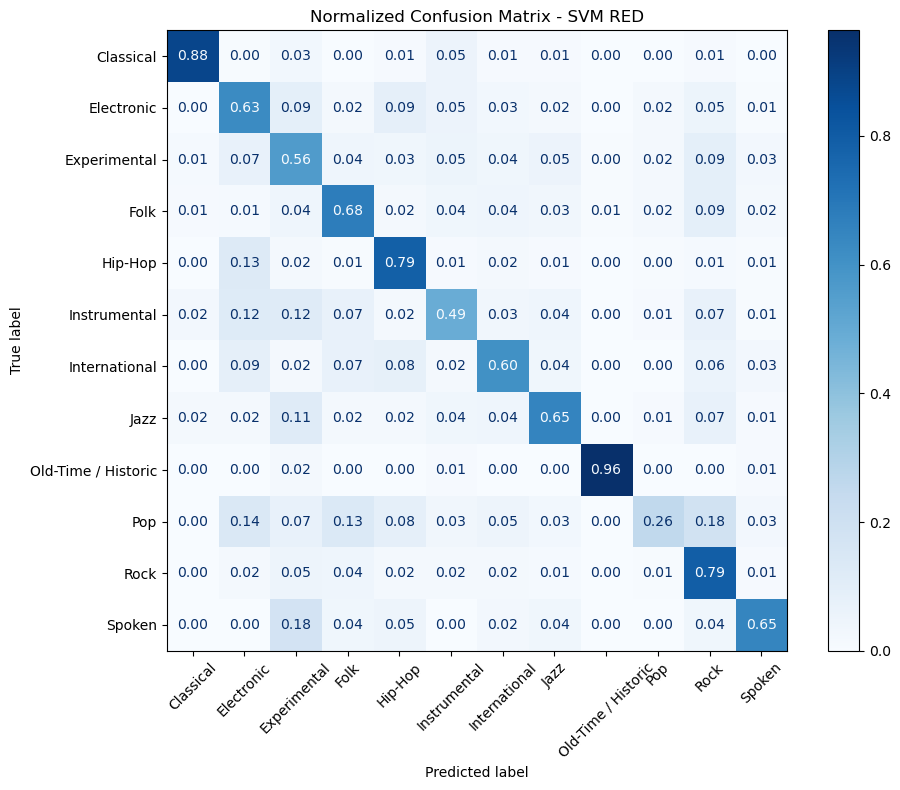

In [37]:
evaluate_model(svm_red, X_train_red_scaled, X_test_red_scaled, y_train, y_test, "SVM RED")

In [38]:
model_name = "SVM_RED"
joblib.dump(svm_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: SVM_RED


In [27]:
from sklearn.linear_model import LogisticRegression, SGDClassifier

logreg = LogisticRegression(max_iter=2000,solver="saga",n_jobs=-1,class_weight="balanced")

logreg_red = LogisticRegression(max_iter=2000,solver="saga",n_jobs=-1,class_weight="balanced")

LogReg ALL accuracy: 0.6388

Classification report:
                     precision    recall  f1-score   support

          Classical       0.78      0.91      0.84       246
         Electronic       0.73      0.59      0.65      1874
       Experimental       0.75      0.50      0.60      2122
               Folk       0.52      0.68      0.59       561
            Hip-Hop       0.59      0.79      0.67       710
       Instrumental       0.35      0.56      0.43       416
      International       0.37      0.67      0.48       278
               Jazz       0.20      0.70      0.31       114
Old-Time / Historic       0.80      0.97      0.88       111
                Pop       0.34      0.41      0.37       466
               Rock       0.87      0.73      0.80      2836
             Spoken       0.23      0.78      0.35        85

           accuracy                           0.64      9819
          macro avg       0.55      0.69      0.58      9819
       weighted avg       0.70 

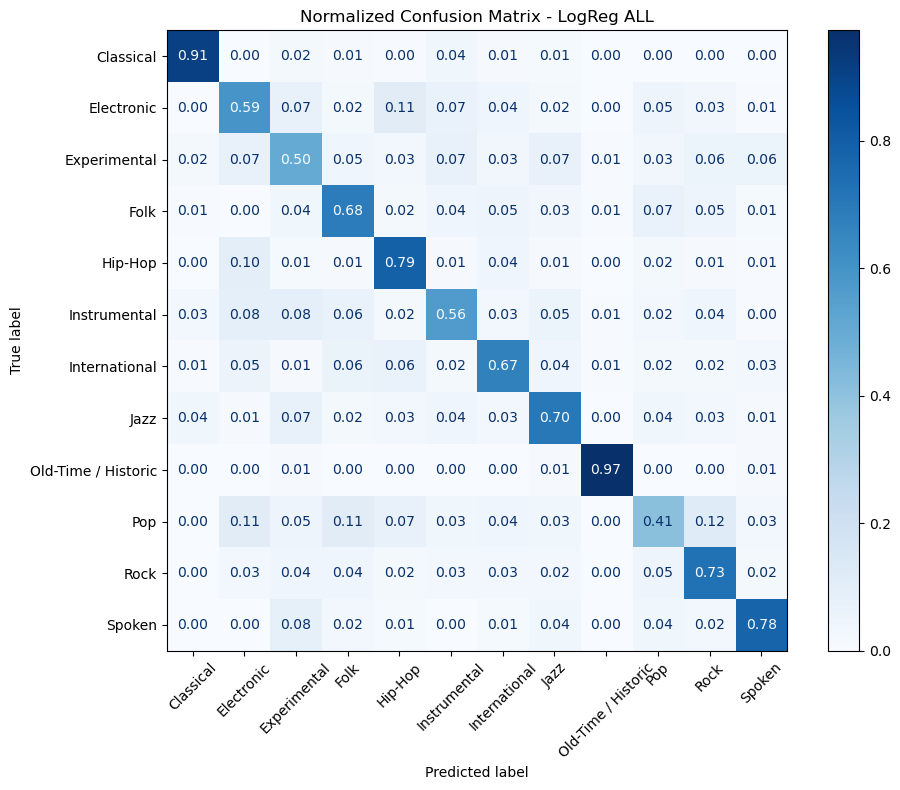

In [28]:
evaluate_model(logreg, X_train_scaled, X_test_scaled, y_train, y_test, "LogReg ALL")

In [29]:
model_name = "LogReg_ALL"
joblib.dump(logreg, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: LogReg_ALL


LogReg RED accuracy: 0.6293

Classification report:
                     precision    recall  f1-score   support

          Classical       0.80      0.92      0.85       246
         Electronic       0.73      0.58      0.64      1874
       Experimental       0.74      0.48      0.58      2122
               Folk       0.50      0.66      0.57       561
            Hip-Hop       0.59      0.79      0.68       710
       Instrumental       0.34      0.57      0.42       416
      International       0.36      0.65      0.46       278
               Jazz       0.20      0.71      0.31       114
Old-Time / Historic       0.80      0.97      0.88       111
                Pop       0.33      0.39      0.36       466
               Rock       0.87      0.73      0.79      2836
             Spoken       0.22      0.79      0.35        85

           accuracy                           0.63      9819
          macro avg       0.54      0.69      0.57      9819
       weighted avg       0.69 

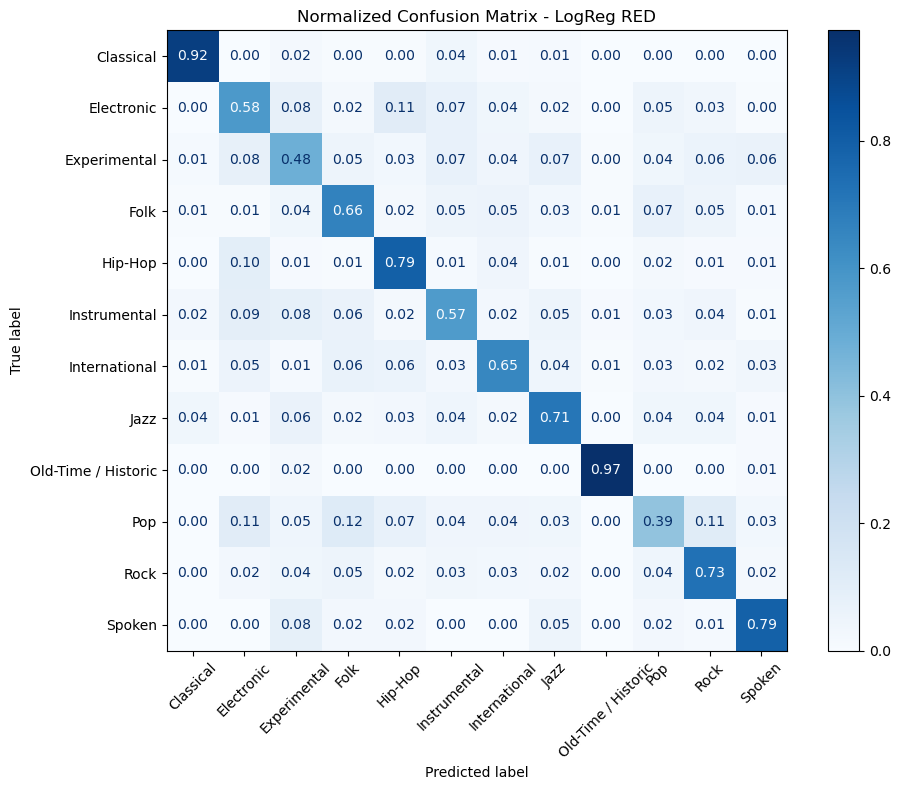

In [28]:
evaluate_model(logreg_red, X_train_red_scaled, X_test_red_scaled, y_train, y_test, "LogReg RED")

In [29]:
model_name = "LogReg_RED"
joblib.dump(logreg_red, model_name)

print("Model sacuvan kao:", model_name)

Model sacuvan kao: LogReg_RED


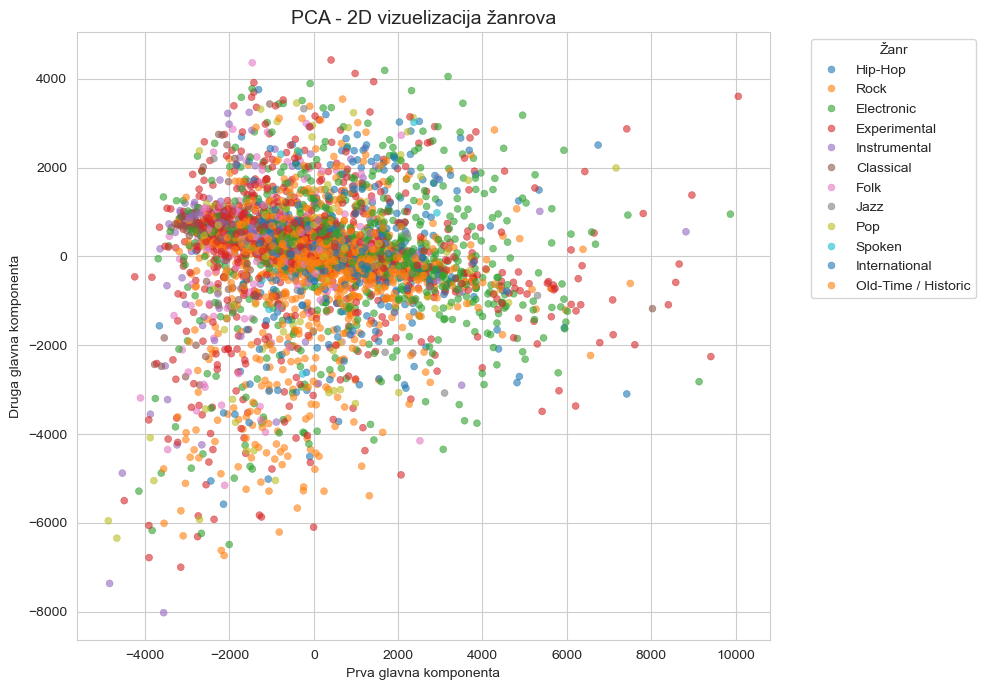

In [55]:
import seaborn as sn

sn.set_style("whitegrid")
plt.figure(figsize=(10,7))

sample_size = 4000
idx = np.random.choice(len(X_pca), sample_size, replace=False)

sn.scatterplot(
    x=X_pca[idx,0],
    y=X_pca[idx,1],
    hue=y.iloc[idx],
    palette="tab10",
    s=25,
    alpha=0.6,
    edgecolor=None
)

plt.title("PCA - 2D vizuelizacija žanrova", fontsize=14)
plt.xlabel("Prva glavna komponenta")
plt.ylabel("Druga glavna komponenta")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left", title="Žanr")
plt.tight_layout()
plt.show()

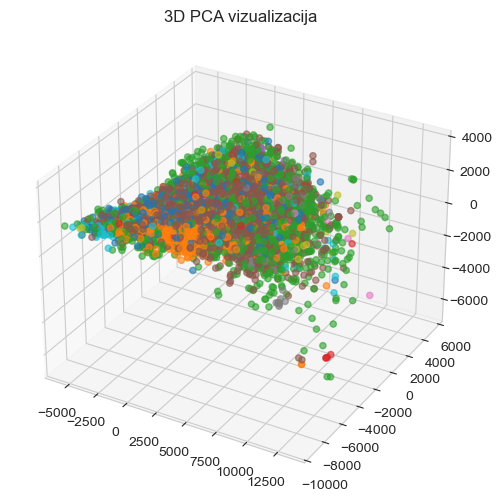

In [56]:
from mpl_toolkits.mplot3d import Axes3D

pca2 = PCA(n_components=3)

X_pca2 = pca2.fit_transform(X_all)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    X_pca2[:,2],
    c=pd.factorize(y)[0],
    cmap="tab10",
    alpha=0.6
)

plt.title("3D PCA vizualizacija")
plt.show()

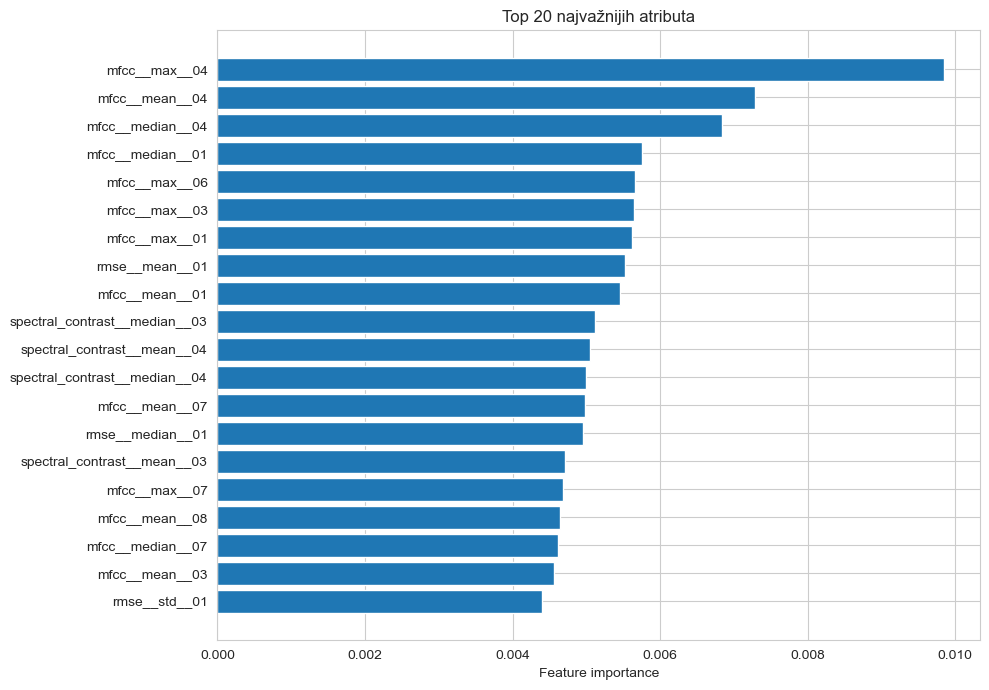

In [83]:
num_features = X_num.columns.tolist()

text_features = tfidf.get_feature_names_out().tolist()

feature_names = num_features + text_features

top = 20

indices = np.argsort(importances)[::-1][:top]
labels = [feature_names[i] for i in indices]

plt.figure(figsize=(10,7))

plt.barh(range(top), importances[indices][::-1])

plt.yticks(range(top), labels[::-1])

plt.title("Top 20 najvažnijih atributa")

plt.xlabel("Feature importance")

plt.tight_layout()
plt.show()

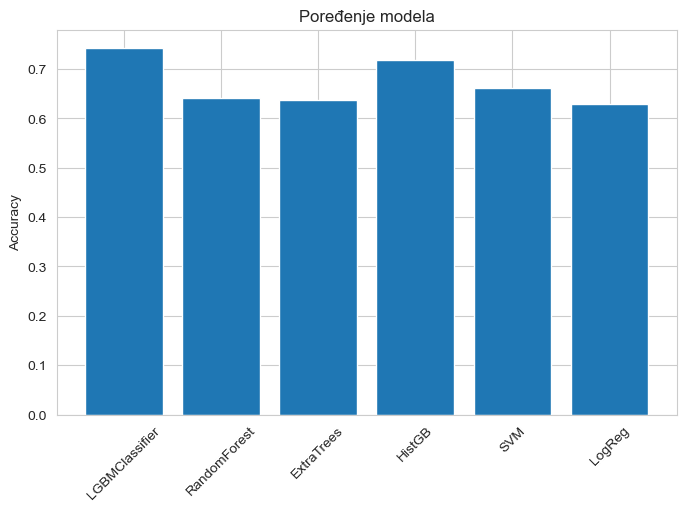

In [58]:
model_names = [
    "LGBMClassifier",
    "RandomForest",
    "ExtraTrees",
    "HistGB",
    "SVM",
    "LogReg",
]

accuracies = [
    accuracy_score(y_test, lgbm_red.predict(X_test_red)),
    accuracy_score(y_test, rf_best.predict(X_test_best)),
    accuracy_score(y_test, et_red.predict(X_test_red)),
    accuracy_score(y_test, gb_red.predict(X_test_red.toarray())),
    accuracy_score(y_test, svm_red.predict(X_test_red_scaled)),
    accuracy_score(y_test, logreg_red.predict(X_test_red_scaled)),
]

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.ylabel("Accuracy")
plt.title("Poređenje modela")

plt.xticks(rotation=45)

plt.show()

In [92]:
pca3 = PCA(n_components=200)

X_train_pca = pca3.fit_transform(X_train_scaled)
X_test_pca = pca3.transform(X_test_scaled)

print("Original shape:", X_train_scaled.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (39276, 2518)
PCA shape: (39276, 200)


RandomForest PCA accuracy: 0.6654

Classification report:
                     precision    recall  f1-score   support

          Classical       0.93      0.74      0.83       246
         Electronic       0.65      0.70      0.68      1874
       Experimental       0.58      0.73      0.65      2122
               Folk       0.65      0.50      0.56       561
            Hip-Hop       0.80      0.53      0.63       710
       Instrumental       0.75      0.19      0.30       416
      International       0.99      0.28      0.44       278
               Jazz       0.93      0.36      0.52       114
Old-Time / Historic       0.90      0.89      0.90       111
                Pop       0.99      0.19      0.32       466
               Rock       0.68      0.85      0.76      2836
             Spoken       0.67      0.35      0.46        85

           accuracy                           0.67      9819
          macro avg       0.79      0.53      0.59      9819
       weighted avg      

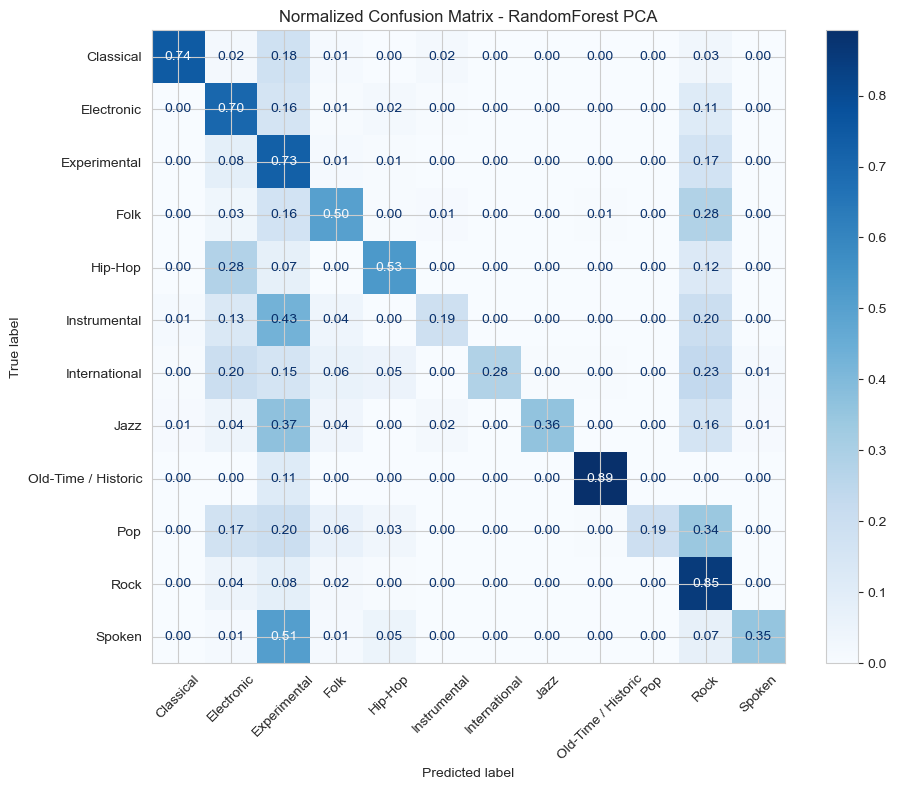

In [93]:
rf_scaled = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_split=4,
    class_weight="balanced",
    n_jobs=-1
)
evaluate_model(rf_scaled, X_train_pca, X_test_pca, y_train, y_test, "RandomForest PCA")

SVM PCA accuracy: 0.6242

Classification report:
                     precision    recall  f1-score   support

          Classical       0.72      0.88      0.79       246
         Electronic       0.69      0.59      0.64      1874
       Experimental       0.71      0.47      0.56      2122
               Folk       0.48      0.68      0.56       561
            Hip-Hop       0.52      0.74      0.61       710
       Instrumental       0.37      0.42      0.39       416
      International       0.34      0.49      0.40       278
               Jazz       0.20      0.65      0.31       114
Old-Time / Historic       0.69      0.97      0.81       111
                Pop       0.73      0.23      0.35       466
               Rock       0.80      0.79      0.79      2836
             Spoken       0.18      0.74      0.29        85

           accuracy                           0.62      9819
          macro avg       0.54      0.64      0.54      9819
       weighted avg       0.67    

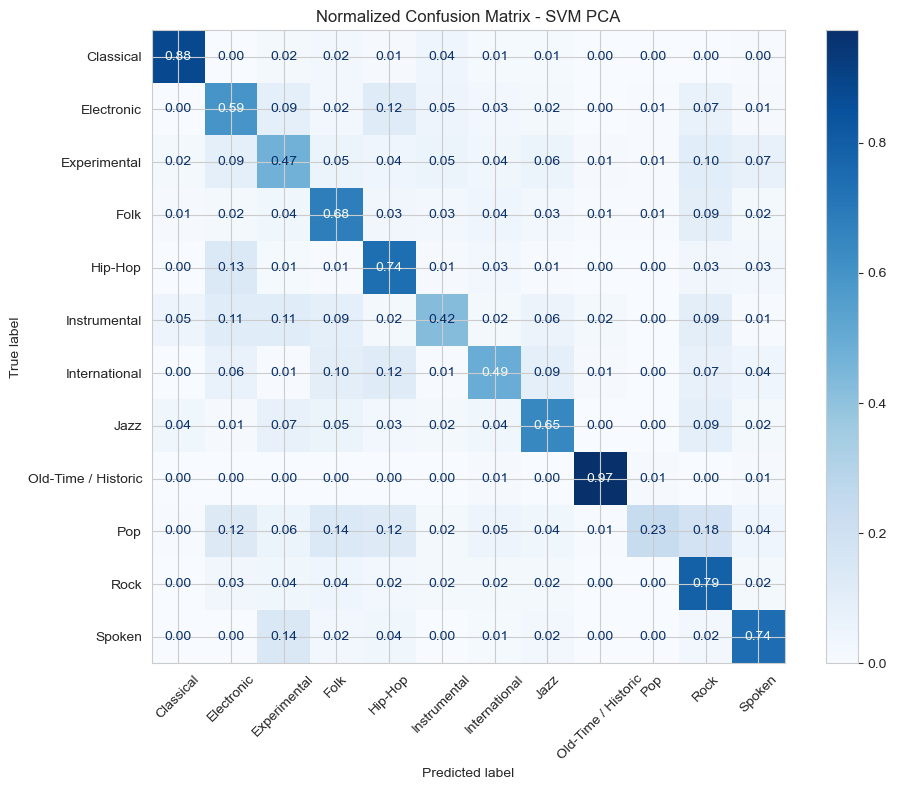

In [94]:
svm_pca = LinearSVC(
    C=2,
    class_weight="balanced",
    max_iter=5000
)
evaluate_model(svm_pca, X_train_pca, X_test_pca, y_train, y_test, "SVM PCA")

LOGREG PCA accuracy: 0.6083

Classification report:
                     precision    recall  f1-score   support

          Classical       0.77      0.89      0.82       246
         Electronic       0.71      0.57      0.63      1874
       Experimental       0.73      0.44      0.55      2122
               Folk       0.49      0.65      0.56       561
            Hip-Hop       0.56      0.76      0.64       710
       Instrumental       0.32      0.52      0.39       416
      International       0.33      0.61      0.43       278
               Jazz       0.19      0.73      0.30       114
Old-Time / Historic       0.75      0.97      0.85       111
                Pop       0.35      0.35      0.35       466
               Rock       0.85      0.72      0.78      2836
             Spoken       0.17      0.79      0.28        85

           accuracy                           0.61      9819
          macro avg       0.52      0.67      0.55      9819
       weighted avg       0.68 

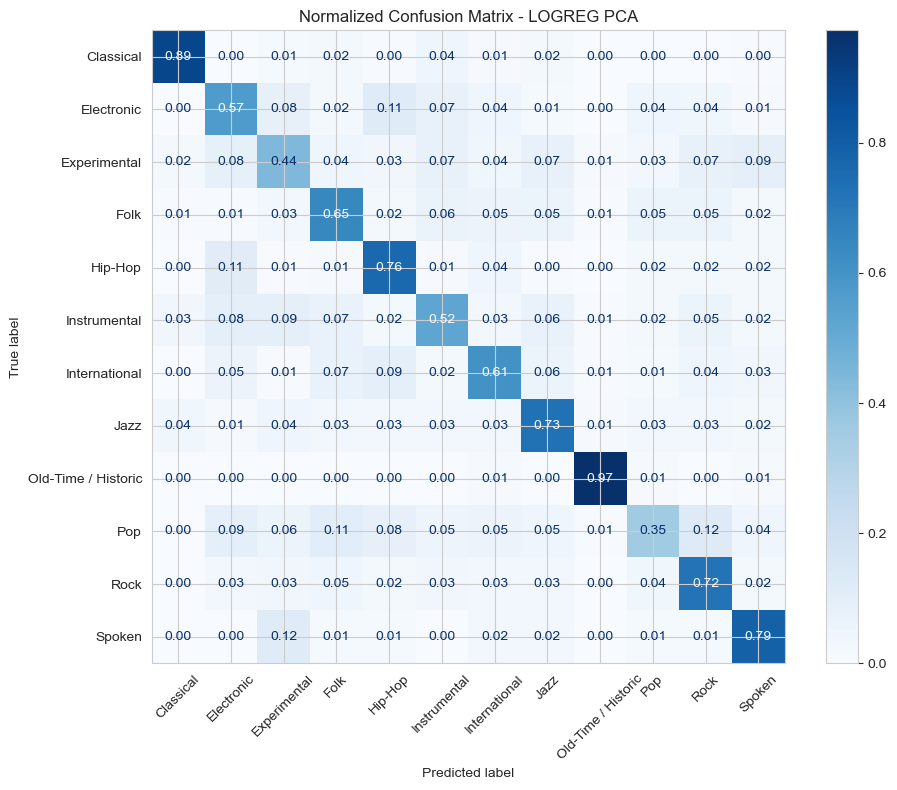

In [95]:
logreg_pca = LogisticRegression(
    C=4,
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    multi_class="multinomial",
    n_jobs=-1
)
evaluate_model(logreg_pca, X_train_pca, X_test_pca, y_train, y_test, "LOGREG PCA")

In [ ]:
for n in [50, 100, 150, 200, 300]:
    
    pca3 = PCA(n_components=n)
    
    X_train_pca1 = pca3.fit_transform(X_train_scaled)
    X_test_pca1 = pca3.transform(X_test_scaled)

    svm1 = LinearSVC(C=2, class_weight="balanced", max_iter=5000)
    
    svm1.fit(X_train_pca1, y_train)
    acc = svm1.score(X_test_pca1, y_test)

    print("PCA:", n, "accuracy:", acc)